## Lightweight Diffusion Models <br><sub>Accelerating Training/Inference for Resource-Constrained Environments</sub>

### Imports

In [13]:
import math
import os
import copy
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torch.utils.data import DataLoader
from tqdm import tqdm

### Globals

In [14]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

# Base model: fetched from the HF hub on first use (downloaded if not already
# cached), so the notebook does NOT depend on any pre-existing local cache.
MODEL_ID = "google/ddpm-cifar10-32"

# Diffusion schedule (linear beta, matching the original DDPM config exactly).
NUM_TRAIN_TIMESTEPS = 1000
BETA_START = 0.0001
BETA_END = 0.02

# Batch size for the baseline DDPM-vs-DDIM image comparison.
GEN_BATCH = 64

# Checkpoint paths used by the Evaluation section. Point these at your files —
# the eval cells load them directly, so you can evaluate without re-training.
CKPT_DISTILLED_8 = "checkpoints/fast_professor_8step.pt"            # full fine-tuned 8-step student
CKPT_LORA_8      = "checkpoints_v3/lora_student_8step.pt"  # per-step LoRA 8-step student
CKPT_SMALL_UNET  = "checkpoints/model_final.pt"         # ~3M lightweight UNet

print(f"Device: {DEVICE}")

Device: cpu


### Utils

In [15]:
def linear_alphas_cumprod(beta_start=BETA_START, beta_end=BETA_END, num_steps=NUM_TRAIN_TIMESTEPS):
    """alpha_bar_t = cumprod(1 - beta_t) for a linear beta schedule."""
    betas = torch.linspace(beta_start, beta_end, num_steps, dtype=torch.float64)
    return torch.cumprod(1.0 - betas, dim=0).float()


def make_training_grid(n_steps, num_train=NUM_TRAIN_TIMESTEPS):
    """Descending DDIM timestep grid (noisy -> clean), matching DDIMScheduler.set_timesteps."""
    step = num_train // n_steps
    ts = (np.arange(0, n_steps) * step).round().astype(np.int64)[::-1].copy()
    return torch.from_numpy(ts)


def ddim_step(eps, x_t, a_s, a_e):
    """One deterministic DDIM step (eta=0): x_t -> x_prev. alphas broadcastable to (B,1,1,1)."""
    x0 = (x_t - (1 - a_s).sqrt() * eps) / a_s.sqrt()
    return a_e.sqrt() * x0 + (1 - a_e).sqrt() * eps


def save_grid(tensor, path, title):
    """Save and show a square grid of images that live in [-1, 1]."""
    imgs = ((tensor.clamp(-1, 1) + 1) / 2).permute(0, 2, 3, 1).cpu().numpy()
    n = int(math.sqrt(len(imgs)))
    fig, axes = plt.subplots(n, n, figsize=(n, n))
    for ax, img in zip(axes.flat, imgs):
        ax.imshow(img)
        ax.axis("off")
    fig.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  => saved {path}")

### Data

In [16]:
def build_dataset(train=True):
    """CIFAR-10 normalized to [-1, 1] with horizontal-flip augmentation."""
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    return datasets.CIFAR10(root="./data", train=train, download=True, transform=transform)

### Network

In [17]:
# --- Building blocks --------------------------------------------------------
# Timestep encoding + the primitive layers (ResNet, self-attention, sampling).

def sinusoidal_embedding(timesteps, dim, downscale_freq_shift=1.0):
    """Fixed sine/cosine timestep encoding (flip_sin_to_cos=False, freq_shift=1)."""
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000)
        * torch.arange(half, dtype=torch.float32, device=timesteps.device)
        / (half - downscale_freq_shift)
    )
    args = timesteps[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimestepEmbedding(nn.Module):
    """Learned MLP that maps the fixed sinusoidal encoding into the model width."""
    def __init__(self, in_ch, embed_dim):
        super().__init__()
        self.linear_1 = nn.Linear(in_ch, embed_dim)
        self.act = nn.SiLU()
        self.linear_2 = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        return self.linear_2(self.act(self.linear_1(x)))


class ResnetBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, temb_ch, groups=32, eps=1e-6):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch, eps=eps, affine=True)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_emb_proj = nn.Linear(temb_ch, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch, eps=eps, affine=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.nonlinearity = nn.SiLU()
        self.conv_shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x, temb):
        h = self.conv1(self.nonlinearity(self.norm1(x)))
        h = h + self.time_emb_proj(self.nonlinearity(temb))[:, :, None, None]
        h = self.conv2(self.nonlinearity(self.norm2(h)))
        if self.conv_shortcut is not None:
            x = self.conv_shortcut(x)
        return x + h


class AttentionBlock(nn.Module):
    """Single-head spatial self-attention.

    Newer diffusers renamed the attention projections (to_q/to_k/to_v/to_out.0).
    The load hook below accepts BOTH namings, so the pretrained weights load with
    strict=True whether the HF hub serves the legacy .bin or a newer .safetensors.
    """
    _KEY_ALIASES = {"to_q": "query", "to_k": "key", "to_v": "value", "to_out.0": "proj_attn"}

    def __init__(self, ch, groups=32, eps=1e-6):
        super().__init__()
        self.group_norm = nn.GroupNorm(groups, ch, eps=eps, affine=True)
        self.query = nn.Linear(ch, ch)
        self.key = nn.Linear(ch, ch)
        self.value = nn.Linear(ch, ch)
        self.proj_attn = nn.Linear(ch, ch)
        self.scale = ch ** -0.5

    def _load_from_state_dict(self, state_dict, prefix, *args, **kwargs):
        for alt, own in self._KEY_ALIASES.items():
            for suffix in ("weight", "bias"):
                alt_key, own_key = prefix + alt + "." + suffix, prefix + own + "." + suffix
                if alt_key in state_dict and own_key not in state_dict:
                    state_dict[own_key] = state_dict.pop(alt_key)
        super()._load_from_state_dict(state_dict, prefix, *args, **kwargs)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.group_norm(x).view(B, C, -1).transpose(1, 2)   # (B, N, C)
        q, k, v = self.query(h), self.key(h), self.value(h)
        attn = torch.softmax(torch.bmm(q, k.transpose(1, 2)) * self.scale, dim=-1)
        h = self.proj_attn(torch.bmm(attn, v))
        return x + h.transpose(1, 2).view(B, C, H, W)


class Downsample2D(nn.Module):
    """Stride-2 conv with asymmetric padding (downsample_padding=0 in the config)."""
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=0)

    def forward(self, x):
        return self.conv(F.pad(x, (0, 1, 0, 1)))


class Upsample2D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        return self.conv(F.interpolate(x, scale_factor=2.0, mode="nearest"))

In [18]:
# --- Encoder / decoder blocks ----------------------------------------------
# Down/up blocks push and pop skip connections onto a shared stack. The "Attn"
# variants interleave a self-attention block after each ResNet.

class DownBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, temb_ch, num_layers=2, add_downsample=True):
        super().__init__()
        self.resnets = nn.ModuleList([
            ResnetBlock2D(in_ch if i == 0 else out_ch, out_ch, temb_ch)
            for i in range(num_layers)
        ])
        self.downsamplers = nn.ModuleList([Downsample2D(out_ch)]) if add_downsample else None

    def forward(self, x, temb):
        skips = ()
        for r in self.resnets:
            x = r(x, temb)
            skips += (x,)
        if self.downsamplers:
            for d in self.downsamplers:
                x = d(x)
            skips += (x,)
        return x, skips


class AttnDownBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, temb_ch, num_layers=2, add_downsample=True):
        super().__init__()
        self.resnets = nn.ModuleList([
            ResnetBlock2D(in_ch if i == 0 else out_ch, out_ch, temb_ch)
            for i in range(num_layers)
        ])
        self.attentions = nn.ModuleList([AttentionBlock(out_ch) for _ in range(num_layers)])
        self.downsamplers = nn.ModuleList([Downsample2D(out_ch)]) if add_downsample else None

    def forward(self, x, temb):
        skips = ()
        for r, a in zip(self.resnets, self.attentions):
            x = a(r(x, temb))
            skips += (x,)
        if self.downsamplers:
            for d in self.downsamplers:
                x = d(x)
            skips += (x,)
        return x, skips


class UNetMidBlock2D(nn.Module):
    def __init__(self, ch, temb_ch):
        super().__init__()
        self.resnets = nn.ModuleList([ResnetBlock2D(ch, ch, temb_ch),
                                      ResnetBlock2D(ch, ch, temb_ch)])
        self.attentions = nn.ModuleList([AttentionBlock(ch)])

    def forward(self, x, temb):
        x = self.attentions[0](self.resnets[0](x, temb))
        return self.resnets[1](x, temb)


class UpBlock2D(nn.Module):
    def __init__(self, resnet_specs, temb_ch, add_upsample=True):
        super().__init__()
        self.resnets = nn.ModuleList([ResnetBlock2D(ic, oc, temb_ch) for ic, oc in resnet_specs])
        self.upsamplers = nn.ModuleList([Upsample2D(resnet_specs[-1][1])]) if add_upsample else None

    def forward(self, x, temb, skip_stack):
        for r in self.resnets:
            x = r(torch.cat([x, skip_stack.pop()], dim=1), temb)
        if self.upsamplers:
            for u in self.upsamplers:
                x = u(x)
        return x


class AttnUpBlock2D(nn.Module):
    def __init__(self, resnet_specs, temb_ch, add_upsample=True):
        super().__init__()
        out_ch = resnet_specs[0][1]
        self.resnets = nn.ModuleList([ResnetBlock2D(ic, oc, temb_ch) for ic, oc in resnet_specs])
        self.attentions = nn.ModuleList([AttentionBlock(out_ch) for _ in resnet_specs])
        self.upsamplers = nn.ModuleList([Upsample2D(out_ch)]) if add_upsample else None

    def forward(self, x, temb, skip_stack):
        for r, a in zip(self.resnets, self.attentions):
            x = a(r(torch.cat([x, skip_stack.pop()], dim=1), temb))
        if self.upsamplers:
            for u in self.upsamplers:
                x = u(x)
        return x

In [19]:
class UNet2DModel(nn.Module):
    """
    Pure-PyTorch UNet matching google/ddpm-cifar10-32. The submodule and parameter
    names line up with the diffusers checkpoint, so the pretrained state_dict loads
    with strict=True.

    block_out_channels=[128, 256, 256, 256], layers_per_block=2
    down: [DownBlock2D, AttnDownBlock2D, DownBlock2D, DownBlock2D]
    up  : [UpBlock2D,   UpBlock2D,       AttnUpBlock2D, UpBlock2D]

    forward(x, t) -> predicted noise (epsilon), shape (B, 3, 32, 32).
    """
    def __init__(self):
        super().__init__()
        temb_dim = 512
        self.conv_in = nn.Conv2d(3, 128, 3, padding=1)
        self.time_embedding = TimestepEmbedding(128, temb_dim)

        self.down_blocks = nn.ModuleList([
            DownBlock2D(128, 128, temb_dim, add_downsample=True),
            AttnDownBlock2D(128, 256, temb_dim, add_downsample=True),
            DownBlock2D(256, 256, temb_dim, add_downsample=True),
            DownBlock2D(256, 256, temb_dim, add_downsample=False),
        ])
        self.mid_block = UNetMidBlock2D(256, temb_dim)

        # in_ch in each (in, out) spec already includes the concatenated skip
        # (e.g. 512 = 256 upsampled + 256 skip; 384 = 256 + 128).
        self.up_blocks = nn.ModuleList([
            UpBlock2D([(512, 256), (512, 256), (512, 256)], temb_dim, add_upsample=True),
            UpBlock2D([(512, 256), (512, 256), (512, 256)], temb_dim, add_upsample=True),
            AttnUpBlock2D([(512, 256), (512, 256), (384, 256)], temb_dim, add_upsample=True),
            UpBlock2D([(384, 128), (256, 128), (256, 128)], temb_dim, add_upsample=False),
        ])

        self.conv_norm_out = nn.GroupNorm(32, 128, eps=1e-6, affine=True)
        self.conv_act = nn.SiLU()
        self.conv_out = nn.Conv2d(128, 3, 3, padding=1)

    def forward(self, x, t):
        temb = self.time_embedding(sinusoidal_embedding(t, 128).to(x.dtype))
        x = self.conv_in(x)

        skip_stack = [x]
        for block in self.down_blocks:
            x, skips = block(x, temb)
            skip_stack.extend(skips)

        x = self.mid_block(x, temb)

        for block in self.up_blocks:
            x = block(x, temb, skip_stack)

        return self.conv_out(self.conv_act(self.conv_norm_out(x)))


def load_state_dict_file(path, device=DEVICE):
    """Load a state dict from a .safetensors or a .bin/.pt checkpoint."""
    if str(path).endswith(".safetensors"):
        from safetensors.torch import load_file
        return load_file(path, device=str(device))
    return torch.load(path, map_location=device, weights_only=True)


def fetch_base_weights():
    """Path to the google/ddpm-cifar10-32 weights — DOWNLOADS from the HF hub if not cached."""
    from huggingface_hub import hf_hub_download
    for fn in ("diffusion_pytorch_model.safetensors", "diffusion_pytorch_model.bin"):
        try:
            return hf_hub_download(MODEL_ID, fn)
        except Exception:                                    # noqa: BLE001 (try next filename)
            continue
    raise FileNotFoundError(f"could not fetch {MODEL_ID} weights from the HF hub")


def load_unet(weights_path=None, device=DEVICE):
    """Build the UNet and load weights.

    Defaults to the pretrained google/ddpm-cifar10-32 weights, fetched from the HF
    hub (downloaded if not already cached). Pass a path to load a local checkpoint.
    AttentionBlock accepts both diffusers key namings, so either file format loads.
    """
    if weights_path is None:
        weights_path = fetch_base_weights()
    model = UNet2DModel().to(device)
    model.load_state_dict(load_state_dict_file(weights_path, device), strict=True)
    return model

#### LoRA progressive distillation — per-step adapter heads

In [20]:
# ── LoRA progressive distillation: per-step adapter heads (script 37) ──────────
# A bank of LoRA heads is attached to the FROZEN base UNet — one head per
# inference step (noise level). At step i, head i is activated before the forward.
# Heads are zero-initialised (B = 0), so an untrained head reproduces the base.

ATTN_LINEAR_NAMES = {"query", "key", "value", "proj_attn"}
RESNET_CONV_NAMES = {"conv1", "conv2"}


class MultiLoRALinear(nn.Module):
    """nn.Linear + a bank of LoRA heads; one head active per forward."""
    def __init__(self, base, num_heads, rank):
        super().__init__()
        self.base = base
        self.lora_A = nn.Parameter(torch.randn(num_heads, rank, base.in_features) / math.sqrt(base.in_features))
        self.lora_B = nn.Parameter(torch.zeros(num_heads, base.out_features, rank))
        self.active = 0

    def forward(self, x):
        h = F.linear(F.linear(x, self.lora_A[self.active]), self.lora_B[self.active])
        return self.base(x) + h


class MultiLoRAConv2d(nn.Module):
    """nn.Conv2d + a bank of LoRA heads (kxk down to rank, then 1x1 up)."""
    def __init__(self, base, num_heads, rank):
        super().__init__()
        self.base = base
        kh, kw = base.kernel_size
        fan_in = base.in_channels * kh * kw
        self.lora_A = nn.Parameter(torch.randn(num_heads, rank, base.in_channels, kh, kw) / math.sqrt(fan_in))
        self.lora_B = nn.Parameter(torch.zeros(num_heads, base.out_channels, rank, 1, 1))
        self.active = 0

    def forward(self, x):
        h = F.conv2d(x, self.lora_A[self.active], stride=self.base.stride, padding=self.base.padding)
        h = F.conv2d(h, self.lora_B[self.active])
        return self.base(x) + h


def add_lora_heads(model, num_heads, rank, targets):
    """Wrap target sub-layers with LoRA banks; freeze everything else.
    targets subset of {"attn","temb","conv"}."""
    for module in list(model.modules()):
        for name, child in list(module.named_children()):
            wrap = None
            if isinstance(child, nn.Linear):
                if ("attn" in targets and name in ATTN_LINEAR_NAMES) or \
                   ("temb" in targets and name == "time_emb_proj"):
                    wrap = MultiLoRALinear(child, num_heads, rank)
            elif isinstance(child, nn.Conv2d) and "conv" in targets and name in RESNET_CONV_NAMES:
                wrap = MultiLoRAConv2d(child, num_heads, rank)
            if wrap is not None:
                setattr(module, name, wrap.to(next(child.parameters()).device))
    for n, p in model.named_parameters():
        p.requires_grad = "lora_" in n
    return model


def set_active_head(model, i):
    for m in model.modules():
        if isinstance(m, (MultiLoRALinear, MultiLoRAConv2d)):
            m.active = i


def lora_state(model):
    return {k: v for k, v in model.state_dict().items() if "lora_" in k}


def make_schedule(n_steps, device=DEVICE):
    """Inference timestep grid (same as generate_n_steps): linspace(999, 0, n)."""
    return torch.linspace(NUM_TRAIN_TIMESTEPS - 1, 0, n_steps, dtype=torch.long, device=device)


def load_lora_student(ckpt_path, device=DEVICE):
    """Rebuild base UNet + LoRA heads from a checkpoint saved by the LoRA trainer."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    model = load_unet(device=device)                 # frozen base (downloads if needed)
    add_lora_heads(model, ckpt["n_steps"], ckpt["rank"], set(ckpt["targets"]))
    model.load_state_dict(ckpt["lora_state"], strict=False)
    return model, ckpt["schedule"].to(device)


@torch.inference_mode()
def generate_lora(model, schedule, alphas, batch_size, device=DEVICE):
    """DDIM sampling along `schedule`, activating head i at step i."""
    x = torch.randn(batch_size, 3, 32, 32, device=device)
    n = len(schedule)
    for i in range(n):
        set_active_head(model, i)
        t = int(schedule[i])
        eps = model(x, torch.full((batch_size,), t, device=device, dtype=torch.long))
        a_s = alphas[t].view(1, 1, 1, 1)
        if i == n - 1:
            x = (x - (1 - a_s).sqrt() * eps) / a_s.sqrt()
        else:
            a_e = alphas[int(schedule[i + 1])].view(1, 1, 1, 1)
            x = ddim_step(eps, x, a_s, a_e)
    return x.clamp(-1, 1)


def run_eval_lora(model, schedule, dataset, device=DEVICE, num_samples=10000, gen_batch=64):
    """FID + IS for a per-step LoRA student (head i active at step i)."""
    ac = linear_alphas_cumprod().to(device)
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    is_metric = InceptionScore(normalize=True).to(device)
    real_loader = DataLoader(dataset, batch_size=128, shuffle=False)
    seen = 0
    with torch.no_grad():
        for imgs, _ in tqdm(real_loader, desc="Real images", leave=False):
            if seen >= num_samples:
                break
            b = ((imgs[:num_samples - seen].to(device) + 1.0) / 2.0)
            fid.update(b, real=True)
            seen += b.shape[0]
    done = 0
    while done < num_samples:
        bs = min(gen_batch, num_samples - done)
        s = (generate_lora(model, schedule, ac, bs, device) + 1.0) / 2.0
        fid.update(s, real=False)
        is_metric.update(s)
        done += bs
        print(f"  generated {done}/{num_samples}", end="\r")
    print(f"\nFID: {fid.compute().item():.4f} | IS: {is_metric.compute()[0].item():.4f}")

#### Post-training quantization

In [21]:
# ── Post-training quantization (quant_code.py) ────────────────────────────────
# Reduce the arithmetic precision of an already-trained UNet (orthogonal to step
# reduction). FP16/BF16 halve the size; INT4 quarters the weight precision.
# INT4-NF4 needs a CUDA GPU + bitsandbytes; an emulated INT4 always works.

def get_model_size_mb(model):
    return sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 ** 2)


def quant_int4_emulated(model):
    """Symmetric per-tensor INT4 fake-quant: round weights to 16 levels, keep float dtype."""
    q = copy.deepcopy(model).cpu()
    with torch.no_grad():
        for param in q.parameters():
            if param.ndim < 2:
                continue
            max_val = param.abs().amax(dim=tuple(range(1, param.ndim)), keepdim=True).clamp(min=1e-8)
            scale = max_val / 7.0
            param.copy_((param / scale).round().clamp(-8, 7) * scale)
    return q


def quant_int4_bnb(model):
    """True INT4 (NF4) via bitsandbytes — requires a CUDA GPU + bitsandbytes installed."""
    import bitsandbytes as bnb
    def _replace(module):
        for name, child in module.named_children():
            if isinstance(child, nn.Linear):
                new = bnb.nn.Linear4bit(child.in_features, child.out_features,
                                        bias=child.bias is not None, quant_type="nf4",
                                        compute_dtype=torch.float16)
                new.weight = bnb.nn.Params4bit(child.weight.data, requires_grad=False, quant_type="nf4")
                if child.bias is not None:
                    new.bias = nn.Parameter(child.bias.data)
                setattr(module, name, new)
            else:
                _replace(child)
    q = copy.deepcopy(model)
    _replace(q)
    return q


def make_quant_variants(model, include_bnb=False):
    """(label, model) variants at different precisions. INT4-NF4 only if include_bnb."""
    variants = [
        ("FP32", copy.deepcopy(model).cpu()),
        ("FP16", copy.deepcopy(model).cpu().half()),
        ("BF16", copy.deepcopy(model).cpu().to(torch.bfloat16)),
        ("INT4-Emu", quant_int4_emulated(model)),
    ]
    if include_bnb:
        variants.append(("INT4-NF4", quant_int4_bnb(model)))
    return variants


@torch.no_grad()
def generate_n_steps_dtype(model, alphas_cumprod, batch_size, device, n_steps):
    """Like generate_n_steps but casts the latent to the model's weight dtype (FP16/BF16/INT4)."""
    model.eval()
    dtype = next(model.parameters()).dtype
    x = torch.randn(batch_size, 3, 32, 32, device=device)
    timesteps = torch.linspace(NUM_TRAIN_TIMESTEPS - 1, 0, n_steps, dtype=torch.long, device=device)
    alphas = alphas_cumprod.to(device)
    for i, t in enumerate(timesteps):
        t_val = t.item()
        eps = model(x.to(dtype), torch.full((batch_size,), t_val, device=device, dtype=torch.long)).float()
        a_s = alphas[t_val].view(1, 1, 1, 1)
        if i == len(timesteps) - 1:
            x = (x - (1 - a_s).sqrt() * eps) / a_s.sqrt()
        else:
            a_e = alphas[timesteps[i + 1].item()].view(1, 1, 1, 1)
            x = ddim_step(eps, x, a_s, a_e)
    return x.clamp(-1, 1)


def run_eval_quant(model, dataset, device=DEVICE, num_samples=10000, steps=8, gen_batch=64):
    """FID + IS for a (possibly quantized) UNet at `steps` DDIM steps."""
    ac = linear_alphas_cumprod().to(device)
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    is_metric = InceptionScore(normalize=True).to(device)
    real_loader = DataLoader(dataset, batch_size=128, shuffle=False)
    seen = 0
    with torch.no_grad():
        for imgs, _ in real_loader:
            if seen >= num_samples:
                break
            b = ((imgs[:num_samples - seen].to(device) + 1.0) / 2.0)
            fid.update(b, real=True)
            seen += b.shape[0]
    done = 0
    with torch.no_grad():
        while done < num_samples:
            bs = min(gen_batch, num_samples - done)
            s = (generate_n_steps_dtype(model, ac, bs, device, steps) + 1.0) / 2.0
            fid.update(s, real=False)
            is_metric.update(s)
            done += bs
    return fid.compute().item(), is_metric.compute()[0].item()

#### Lightweight ~3M UNet

In [22]:
# ── Lightweight ~3M UNet (unet3M_lora.py) ─────────────────────────────────────
# A from-scratch compact UNet with FiLM time-conditioning, per-noise-band LoRA on
# the time projections (4 bands), a cosine schedule, and EMA weights for sampling.

LORA_BANDS = [(0, 249), (250, 499), (500, 749), (750, 999)]
N_LORA_BANDS = len(LORA_BANDS)


def get_band(t):
    """Map timestep -> band index (same device/shape as t)."""
    band = torch.zeros_like(t)
    for i, (lo, hi) in enumerate(LORA_BANDS):
        band = torch.where((t >= lo) & (t <= hi), torch.full_like(t, i), band)
    return band


def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    ac = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac = ac / ac[0]
    return (1 - ac[1:] / ac[:-1]).clamp(1e-4, 0.9999)


class SmallDiffusionSchedule:
    """Cosine-schedule forward process + DDIM sampler for the lightweight UNet."""
    def __init__(self):
        betas = cosine_beta_schedule(NUM_TRAIN_TIMESTEPS).to(DEVICE)
        self.alphas_bar = torch.cumprod(1.0 - betas, dim=0)
        self.sqrt_ab = self.alphas_bar.sqrt()
        self.sqrt_one_minus_ab = (1 - self.alphas_bar).sqrt()

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        s = self.sqrt_ab[t].view(-1, 1, 1, 1)
        sm = self.sqrt_one_minus_ab[t].view(-1, 1, 1, 1)
        return s * x0 + sm * noise, noise

    @torch.no_grad()
    def ddim_sample(self, model, shape, steps=20, eta=0.0):
        model.eval()
        b = shape[0]
        x = torch.randn(shape, device=DEVICE)
        ts = torch.linspace(NUM_TRAIN_TIMESTEPS - 1, 0, steps, dtype=torch.long, device=DEVICE)
        for i, t_cur in enumerate(ts):
            t_b = t_cur.expand(b)
            band = get_band(t_b)
            ab_cur = self.alphas_bar[t_cur]
            ab_prev = self.alphas_bar[ts[i + 1]] if i + 1 < len(ts) else torch.tensor(1.0, device=DEVICE)
            eps = model(x, t_b, band)
            x0_pred = ((x - self.sqrt_one_minus_ab[t_cur] * eps) / self.sqrt_ab[t_cur]).clamp(-1, 1)
            sigma = eta * ((1 - ab_prev) / (1 - ab_cur) * (1 - ab_cur / ab_prev)).sqrt()
            dir_xt = (1 - ab_prev - sigma ** 2).sqrt() * eps
            noise = sigma * torch.randn_like(x) if eta > 0 else 0.0
            x = ab_prev.sqrt() * x0_pred + dir_xt + noise
        return (x.clamp(-1, 1) + 1) / 2     # -> [0, 1]


class LoRALinear(nn.Module):
    """Linear with one (A,B) LoRA pair per noise band (B zero-init -> identity)."""
    def __init__(self, in_f, out_f, rank=8, bias=True):
        super().__init__()
        self.linear = nn.Linear(in_f, out_f, bias=bias)
        self.scale = 1.0 / rank
        self.lora_A = nn.Parameter(torch.randn(N_LORA_BANDS, rank, in_f) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(N_LORA_BANDS, out_f, rank))

    def forward(self, x, band):
        base = self.linear(x)
        A, B = self.lora_A[band], self.lora_B[band]
        delta = torch.bmm(B, torch.bmm(A, x.unsqueeze(-1))).squeeze(-1)
        return base + self.scale * delta


class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device, dtype=torch.float) / (half - 1))
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


def safe_group_norm(n_groups, channels):
    g = next(g for g in range(n_groups, 0, -1) if channels % g == 0)
    return nn.GroupNorm(g, channels)


class ResBlock(nn.Module):
    """GroupNorm + Conv residual block with FiLM time-conditioning via a band LoRALinear."""
    def __init__(self, in_ch, out_ch, time_dim, lora_rank=8, n_groups=8):
        super().__init__()
        self.norm1 = safe_group_norm(n_groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = safe_group_norm(n_groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = LoRALinear(time_dim, out_ch * 2, rank=lora_rank)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, band):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.time_mlp(t_emb, band).chunk(2, dim=-1)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SmallDownsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x, *_):
        return self.op(x)


class SmallUpsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x, *_):
        return self.op(F.interpolate(x, scale_factor=2, mode="nearest"))


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = safe_group_norm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
        self.scale = ch ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x)).view(B, 3, C, H * W)
        q, k, v = qkv.unbind(dim=1)
        attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) * self.scale, dim=-1)
        out = torch.bmm(v, attn.transpose(1, 2)).view(B, C, H, W)
        return x + self.proj(out)


class SmallUNet(nn.Module):
    """~3M-param UNet; ch_mult=(1,2,2) -> [64,128,128]; attention at the bottleneck."""
    def __init__(self, in_ch=3, base_ch=64, ch_mult=(1, 2, 2), time_dim=128, lora_rank=8):
        super().__init__()
        chs = [base_ch * m for m in ch_mult]
        self.time_mlp = nn.Sequential(SinusoidalPE(time_dim),
                                      nn.Linear(time_dim, time_dim * 4), nn.SiLU(),
                                      nn.Linear(time_dim * 4, time_dim))
        self.init_conv = nn.Conv2d(in_ch, chs[0], 3, padding=1)
        self.enc_blocks, self.downs = nn.ModuleList(), nn.ModuleList()
        ch = chs[0]
        for ch_out in chs[1:]:
            self.enc_blocks.append(ResBlock(ch, ch_out, time_dim, lora_rank))
            self.downs.append(SmallDownsample(ch_out))
            ch = ch_out
        self.mid_res1 = ResBlock(ch, ch, time_dim, lora_rank)
        self.mid_attn = SelfAttention(ch)
        self.mid_res2 = ResBlock(ch, ch, time_dim, lora_rank)
        self.dec_blocks, self.ups = nn.ModuleList(), nn.ModuleList()
        for ch_skip in reversed(chs[1:]):
            self.ups.append(SmallUpsample(ch))
            self.dec_blocks.append(ResBlock(ch + ch_skip, ch_skip, time_dim, lora_rank))
            ch = ch_skip
        self.out_res = ResBlock(ch, chs[0], time_dim, lora_rank)
        self.out = nn.Sequential(safe_group_norm(8, chs[0]), nn.SiLU(), nn.Conv2d(chs[0], in_ch, 1))

    def forward(self, x, t, band):
        t_emb = self.time_mlp(t)
        h = self.init_conv(x)
        skips = []
        for res, down in zip(self.enc_blocks, self.downs):
            h = res(h, t_emb, band)
            skips.append(h)
            h = down(h)
        h = self.mid_res1(h, t_emb, band)
        h = self.mid_attn(h)
        h = self.mid_res2(h, t_emb, band)
        for up, res, skip in zip(self.ups, self.dec_blocks, reversed(skips)):
            h = up(h)
            h = torch.cat([h, skip], dim=1)
            h = res(h, t_emb, band)
        h = self.out_res(h, t_emb, band)
        return self.out(h)


class EMA:
    """Exponential moving average of weights; apply() before sampling, restore() to resume."""
    def __init__(self, model, decay=0.9999):
        self.model, self.decay = model, decay
        self.shadow = copy.deepcopy(model.state_dict())

    @torch.no_grad()
    def update(self):
        for k, v in self.model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self):
        self._backup = copy.deepcopy(self.model.state_dict())
        self.model.load_state_dict(self.shadow)

    def restore(self):
        self.model.load_state_dict(self._backup)

    def state_dict(self):
        return self.shadow

    def load_state_dict(self, sd):
        self.shadow = sd


def load_small_unet(ckpt_path, device=DEVICE):
    """Load the lightweight UNet with EMA weights applied (the sampling configuration)."""
    model = SmallUNet().to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model"])
    ema = EMA(model)
    ema.load_state_dict(ckpt["ema"])
    ema.apply()
    model.eval()
    return model


def run_eval_small(model, schedule, dataset, device=DEVICE, num_samples=10000, steps=50, gen_batch=128):
    """FID + IS for the lightweight UNet (its DDIM sampler returns images in [0,1])."""
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    is_metric = InceptionScore(normalize=True).to(device)
    real_loader = DataLoader(dataset, batch_size=128, shuffle=False)
    seen = 0
    with torch.no_grad():
        for imgs, _ in tqdm(real_loader, desc="Real images", leave=False):
            if seen >= num_samples:
                break
            b = ((imgs[:num_samples - seen].to(device) + 1.0) / 2.0)
            fid.update(b, real=True)
            seen += b.shape[0]
    done = 0
    with torch.no_grad():
        while done < num_samples:
            bs = min(gen_batch, num_samples - done)
            s = schedule.ddim_sample(model, (bs, 3, 32, 32), steps=steps)   # [0,1]
            fid.update(s, real=False)
            is_metric.update(s)
            done += bs
            print(f"  generated {done}/{num_samples}", end="\r")
    print(f"\nFID: {fid.compute().item():.4f} | IS: {is_metric.compute()[0].item():.4f}")

### Train

In [ ]:
def progressive_distill(teacher, *, grid_steps, teacher_jump, eval_steps,
                        loss_type="mse_position", lr=1e-5, epochs=5,
                        grad_clip=None, batch_size=32, save_path=None):
    """
    One stage of progressive distillation.

    The teacher takes `teacher_jump` DDIM steps on a `grid_steps`-point grid; the
    student (a clone of the teacher) learns to reproduce that move in a single step,
    which halves/thirds the number of inference steps needed.

    loss_type:
      "mse_position" -> MSE between the student's 1-step result and the teacher's
                        multi-step result            (stages 1000->25 and 25->12)
      "huber_x0"     -> Huber loss on the implied x0 predictions, with gradient
                        clipping                       (stage 12->8)
    """
    ac = linear_alphas_cumprod().to(DEVICE)
    timesteps = make_training_grid(grid_steps).to(DEVICE)

    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    student = copy.deepcopy(teacher).to(DEVICE)
    student.train()
    for p in student.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW(student.parameters(), lr=lr)
    loader = DataLoader(build_dataset(), batch_size=batch_size, shuffle=True, drop_last=True)

    print(f"Distilling: {teacher_jump}-step teacher jump on a {grid_steps}-step grid "
          f"-> {eval_steps}-step student  (loss={loss_type})")

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"Epoch {epoch + 1}/{epochs}")
        for imgs, _ in pbar:
            imgs = imgs.to(DEVICE)
            B = imgs.shape[0]
            noise = torch.randn_like(imgs)

            # Random start, leaving room for `teacher_jump` steps ahead on the grid.
            idx = torch.randint(0, len(timesteps) - teacher_jump, (B,), device=DEVICE)
            t_start = timesteps[idx]
            t_target = timesteps[idx + teacher_jump]
            a0 = ac[t_start].view(-1, 1, 1, 1)
            a_target = ac[t_target].view(-1, 1, 1, 1)

            x_t = a0.sqrt() * imgs + (1 - a0).sqrt() * noise

            # Teacher: `teacher_jump` sequential DDIM steps (frozen, no grad).
            with torch.no_grad():
                x_ref = x_t.clone()
                for i in range(teacher_jump):
                    t_curr = timesteps[idx + i]
                    t_next = timesteps[idx + i + 1]
                    eps = teacher(x_ref, t_curr)
                    a_s = ac[t_curr].view(-1, 1, 1, 1)
                    a_e = ac[t_next].view(-1, 1, 1, 1)
                    x_ref = ddim_step(eps, x_ref, a_s, a_e)

            # Student: a single jump from t_start to t_target.
            s_eps = student(x_t, t_start)
            x0_student = (x_t - (1 - a0).sqrt() * s_eps) / a0.sqrt()

            if loss_type == "mse_position":
                x_fast = a_target.sqrt() * x0_student + (1 - a_target).sqrt() * s_eps
                loss = F.mse_loss(x_fast, x_ref.detach())
            elif loss_type == "huber_x0":
                # x0 the teacher implies, expressed through the student's noise direction.
                x0_target = (x_ref - (1 - a_target).sqrt() * s_eps.detach()) / a_target.sqrt()
                loss = F.huber_loss(x0_student, x0_target.detach(), delta=1.0)
            else:
                raise ValueError(f"unknown loss_type: {loss_type}")

            optimizer.zero_grad()
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(student.parameters(), grad_clip)
            optimizer.step()
            pbar.set_postfix({"loss": f"{loss.item():.7f}"})

    if save_path:
        torch.save(student.state_dict(), save_path)
        print(f"Saved {save_path}")

    return student

Progressive distillation runs in three sequential stages, each halving (or
thirding) the number of inference steps. Every stage loads the previous stage's
checkpoint as its frozen teacher, so run them in order.

| Stage | Steps | Teacher | Grid | Jump | Loss |
|-------|-------|---------|------|------|------|
| 1 | 1000 → 25 | google DDPM | 100 | 4 | MSE on position |
| 2 | 25 → 12 | `fast_professor_21_final.pt` | 24 | 2 | MSE on position |
| 3 | 12 → 8 | `fast_professor_12step.pt` | 24 | 3 | Huber on x0 + grad clip |

In [ ]:
# Stage 1: 1000 -> 25 steps  (teacher = original google DDPM, 4-step jump)
teacher = load_unet()  # pretrained google/ddpm-cifar10-32
student_25 = progressive_distill(
    teacher,
    grid_steps=100, teacher_jump=4, eval_steps=25,
    loss_type="mse_position", lr=1e-5, epochs=5,
    save_path="fast_professor_21_final.pt",
)

In [ ]:
# Stage 2: 25 -> 12 steps  (2-step teacher jump)
teacher_25 = load_unet("fast_professor_21_final.pt")
student_12 = progressive_distill(
    teacher_25,
    grid_steps=24, teacher_jump=2, eval_steps=12,
    loss_type="mse_position", lr=1e-5, epochs=5,
    save_path="fast_professor_12step.pt",
)

In [ ]:
# Stage 3: 12 -> 8 steps  (3-step teacher jump, Huber-on-x0 loss + grad clipping)
teacher_12 = load_unet("fast_professor_12step.pt")
student_8 = progressive_distill(
    teacher_12,
    grid_steps=24, teacher_jump=3, eval_steps=8,
    loss_type="huber_x0", lr=8e-6, epochs=5, grad_clip=1.0,
    save_path="fast_professor_8step.pt",
)

#### LoRA progressive distillation — training

Same progressive-distillation idea as above, but the base UNet is frozen and only a
bank of per-step LoRA heads is trained (one head per inference step). The best recipe
found: stage 1 distils the base to 25 heads (rank 4, attn+temb+conv); stage 2 distils
that to 8 heads (rank 8). Skip to Evaluation if you already have the checkpoints.

In [ ]:
def warm_start_from_teacher(student, s_sched, teacher, t_sched):
    """Copy each student head from the teacher head nearest in timestep (shape permitting)."""
    t_mods = dict(teacher.named_modules())
    nearest = [int((t_sched - int(t)).abs().argmin()) for t in s_sched]
    for name, sm in student.named_modules():
        if not isinstance(sm, (MultiLoRALinear, MultiLoRAConv2d)):
            continue
        tm = t_mods.get(name)
        if type(tm) is not type(sm) or tm.lora_A.shape[1:] != sm.lora_A.shape[1:]:
            continue
        with torch.no_grad():
            for i, j in enumerate(nearest):
                sm.lora_A[i].copy_(tm.lora_A[j])
                sm.lora_B[i].copy_(tm.lora_B[j])


def teacher_eps(teacher, t_sched, x, t):
    """Query the teacher at timestep t; if it has heads, activate the one nearest to t."""
    if t_sched is not None:
        set_active_head(teacher, int((t_sched - t).abs().argmin()))
    return teacher(x, torch.full((x.shape[0],), t, device=x.device, dtype=torch.long))


def lora_distill_stage(n_steps, teacher, teacher_sched, *, substeps, loss_type="mse_position",
                       rank=4, targets=("attn", "temb"), lr=1e-4, epochs=5,
                       batch_size=32, save_path=None):
    """One LoRA progressive-distillation stage (per-step heads). Mirrors script 37.

    The teacher traverses each student jump in `substeps` DDIM steps (activating its
    own nearest head); the student learns to cover it in one step with head i.
    loss_type: "mse_position" (25/12 stages) or "huber_x0" (8-step stage).
    """
    alphas = linear_alphas_cumprod().to(DEVICE)
    schedule = make_schedule(n_steps)

    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad_(False)

    student = load_unet(device=DEVICE)
    add_lora_heads(student, n_steps, rank, set(targets))
    if teacher_sched is not None:
        warm_start_from_teacher(student, schedule, teacher, teacher_sched)
    student.train()

    trainable = [p for p in student.parameters() if p.requires_grad]
    print(f"{n_steps}-step student | {sum(p.numel() for p in trainable) / 1e6:.2f}M trainable LoRA params")
    optimizer = torch.optim.AdamW(trainable, lr=lr)
    loader = DataLoader(build_dataset(), batch_size=batch_size, shuffle=True, drop_last=True)

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"{n_steps}-step | epoch {epoch + 1}/{epochs}")
        for imgs, _ in pbar:
            imgs = imgs.to(DEVICE)
            i = int(torch.randint(0, n_steps - 1, (1,)))     # one head per batch
            t_start, t_target = int(schedule[i]), int(schedule[i + 1])
            a_s = alphas[t_start].view(1, 1, 1, 1)
            a_e = alphas[t_target].view(1, 1, 1, 1)
            noise = torch.randn_like(imgs)
            x_t = a_s.sqrt() * imgs + (1 - a_s).sqrt() * noise

            with torch.no_grad():
                sub = torch.linspace(t_start, t_target, substeps + 1).round().long()
                x_ref = x_t.clone()
                for j in range(substeps):
                    eps = teacher_eps(teacher, teacher_sched, x_ref, int(sub[j]))
                    aj = alphas[int(sub[j])].view(1, 1, 1, 1)
                    aj1 = alphas[int(sub[j + 1])].view(1, 1, 1, 1)
                    x_ref = ddim_step(eps, x_ref, aj, aj1)

            set_active_head(student, i)
            s_eps = student(x_t, torch.full((imgs.shape[0],), t_start, device=DEVICE, dtype=torch.long))
            x0_s = (x_t - (1 - a_s).sqrt() * s_eps) / a_s.sqrt()
            if loss_type == "huber_x0":
                x0_ref = (x_ref - (1 - a_e).sqrt() * s_eps.detach()) / a_e.sqrt()
                loss = F.huber_loss(x0_s, x0_ref.detach(), delta=1.0)
            else:
                x_fast = a_e.sqrt() * x0_s + (1 - a_e).sqrt() * s_eps
                loss = F.mse_loss(x_fast, x_ref.detach())

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            pbar.set_postfix({"head": i, "loss": f"{loss.item():.6f}"})

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        torch.save({"n_steps": n_steps, "rank": rank, "targets": sorted(targets),
                    "schedule": schedule.cpu(), "lora_state": lora_state(student)}, save_path)
        print(f"Saved {save_path}")
    return student, schedule

In [ ]:
# LoRA stage 1 (best 25-step): base -> 25 heads, rank 4, attn+temb+conv, 8 sub-steps.
base = load_unet()                                   # frozen google DDPM (downloads if needed)
lora_student_25, lora_sched_25 = lora_distill_stage(
    25, base, None, substeps=8, loss_type="mse_position",
    rank=4, targets=("attn", "temb", "conv"), lr=1e-4, epochs=15,
    save_path="checkpoints_v2/lora_student_25step.pt",
)

In [ ]:
# LoRA stage 2 (best 8-step): 25-step LoRA teacher -> 8 heads, rank 8, direct, 4 sub-steps.
# (rank 8 != teacher rank 4, so warm-start is skipped and heads start from zero — fine.)
teacher_25, sched_25 = load_lora_student("checkpoints_v2/lora_student_25step.pt")
lora_student_8, lora_sched_8 = lora_distill_stage(
    8, teacher_25, sched_25, substeps=4, loss_type="huber_x0",
    rank=8, targets=("attn", "temb", "conv"), lr=1e-4, epochs=15,
    save_path=CKPT_LORA_8,
)

#### Lightweight UNet — training from scratch

The ~3M UNet is trained from scratch (no teacher) with a cosine schedule and EMA.
Run the cells below to train, or skip straight to Evaluation if you have a checkpoint.

In [ ]:
def train_small_unet(epochs=500, lr=2e-4, batch_size=128, lora_rank=8,
                     save_path=CKPT_SMALL_UNET):
    """Train the lightweight UNet from scratch: cosine schedule, eps-prediction, EMA."""
    schedule = SmallDiffusionSchedule()
    model = SmallUNet(lora_rank=lora_rank).to(DEVICE)
    ema = EMA(model)
    tf = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(),
                             transforms.Normalize([0.5] * 3, [0.5] * 3)])     # -> [-1, 1]
    loader = DataLoader(datasets.CIFAR10("./data", train=True, download=True, transform=tf),
                        batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    lr_sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(loader), eta_min=lr / 10)
    scaler = torch.amp.GradScaler(DEVICE, enabled=(DEVICE == "cuda"))
    print(f"Training SmallUNet ({sum(p.numel() for p in model.parameters())/1e6:.2f}M params) "
          f"for {epochs} epochs")

    for epoch in range(1, epochs + 1):
        model.train()
        bar = tqdm(loader, desc=f"epoch {epoch}/{epochs}")
        for x, _ in bar:
            x = x.to(DEVICE)
            t = torch.randint(0, NUM_TRAIN_TIMESTEPS, (x.size(0),), device=DEVICE)
            band = get_band(t)
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                x_t, noise = schedule.q_sample(x, t)
                loss = F.mse_loss(model(x_t, t, band), noise)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            lr_sched.step()
            ema.update()
            bar.set_postfix(loss=f"{loss.item():.4f}")

    torch.save({"model": model.state_dict(), "ema": ema.state_dict()}, save_path)
    print(f"Saved {save_path}")
    return model, ema

In [ ]:
# Train the lightweight ~3M UNet from scratch (slow: 500 epochs for the paper config).
# Skip this cell if you already have a checkpoint — the Evaluation section loads it.
small_model, small_ema = train_small_unet(
    epochs=500, lr=2e-4, batch_size=128, lora_rank=8,
    save_path=CKPT_SMALL_UNET,
)

### Evaluation

In [23]:
# --- Full-trajectory schedulers (used only for the original-model baseline) ---

class DDPMSchedulerFull:
    """Stochastic DDPM reverse process over all 1000 steps (variance_type=fixed_large)."""
    def __init__(self):
        self.alphas_cumprod = linear_alphas_cumprod()
        self.timesteps = torch.arange(NUM_TRAIN_TIMESTEPS - 1, -1, -1)

    @torch.no_grad()
    def step(self, eps, t, x_t):
        a_t = self.alphas_cumprod[t].to(x_t.device)
        a_prev = self.alphas_cumprod[t - 1].to(x_t.device) if t > 0 else torch.tensor(1.0)
        beta_t = 1 - a_t / a_prev
        x0 = ((x_t - (1 - a_t).sqrt() * eps) / a_t.sqrt()).clamp(-1, 1)
        coef1 = a_prev.sqrt() * beta_t / (1 - a_t)
        coef2 = (a_t / a_prev).sqrt() * (1 - a_prev) / (1 - a_t)
        mean = coef1 * x0 + coef2 * x_t
        if t > 0:
            mean = mean + beta_t.sqrt() * torch.randn_like(x_t)
        return mean


class DDIMSchedulerFull:
    """Deterministic DDIM (eta=0) over a strided grid, same linear betas."""
    def __init__(self, num_inference_steps=30):
        self.alphas_cumprod = linear_alphas_cumprod()
        self._step = NUM_TRAIN_TIMESTEPS // num_inference_steps
        ts = (np.arange(0, num_inference_steps) * self._step).round().astype(np.int64)[::-1].copy()
        self.timesteps = torch.from_numpy(ts)

    @torch.no_grad()
    def step(self, eps, t, x_t):
        a_t = self.alphas_cumprod[t].to(x_t.device)
        prev_t = t - self._step
        a_prev = self.alphas_cumprod[prev_t].to(x_t.device) if prev_t >= 0 else torch.tensor(1.0)
        x0 = (x_t - (1 - a_t).sqrt() * eps) / a_t.sqrt()
        return a_prev.sqrt() * x0 + (1 - a_prev).sqrt() * eps


@torch.no_grad()
def run_sampler(model, scheduler, batch, device, seed=SEED):
    """Run a full reverse-diffusion loop with the given scheduler. Returns (images, seconds)."""
    torch.manual_seed(seed)
    x = torch.randn(batch, 3, 32, 32, device=device)
    t0 = time.time()
    for t in scheduler.timesteps:
        t_b = torch.full((batch,), t.item(), device=device, dtype=torch.long)
        x = scheduler.step(model(x, t_b), t.item(), x)
    return x, time.time() - t0

In [24]:
@torch.no_grad()
def generate_n_steps(model, alphas_cumprod, batch_size, device, n_steps):
    """Generate a batch with n_steps linearly spaced DDIM steps (the few-step sampler)."""
    model.eval()
    x = torch.randn(batch_size, 3, 32, 32, device=device)
    timesteps = torch.linspace(NUM_TRAIN_TIMESTEPS - 1, 0, n_steps, dtype=torch.long, device=device)
    alphas = alphas_cumprod.to(device)
    for i, t in enumerate(timesteps):
        t_val = t.item()
        t_b = torch.full((batch_size,), t_val, device=device, dtype=torch.long)
        eps = model(x, t_b)
        a_s = alphas[t_val].view(1, 1, 1, 1)
        if i == len(timesteps) - 1:
            x = (x - (1 - a_s).sqrt() * eps) / a_s.sqrt()
        else:
            a_e = alphas[timesteps[i + 1].item()].view(1, 1, 1, 1)
            x = ddim_step(eps, x, a_s, a_e)
    return x.clamp(-1, 1)


def run_eval(model, dataset, device, num_samples=10000, steps=25, gen_batch=64):
    """FID + IS for `model` generated at `steps` DDIM steps vs. real CIFAR-10."""
    print(f"\n--- Evaluating {num_samples} samples at {steps} steps ---")
    ac = linear_alphas_cumprod()
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    is_metric = InceptionScore(normalize=True).to(device)

    # Real images (streamed in [0, 1]).
    real_loader = DataLoader(dataset, batch_size=128, shuffle=False)
    real_count = 0
    with torch.no_grad():
        for imgs, _ in tqdm(real_loader, desc="Real images", leave=False):
            if real_count >= num_samples:
                break
            batch = (imgs[:num_samples - real_count].to(device) + 1.0) / 2.0
            fid.update(batch, real=True)
            real_count += batch.shape[0]

    # Fake images (generated in chunks).
    fake_count = 0
    with torch.no_grad():
        while fake_count < num_samples:
            bs = min(gen_batch, num_samples - fake_count)
            samples = (generate_n_steps(model, ac, bs, device, steps) + 1.0) / 2.0
            fid.update(samples, real=False)
            is_metric.update(samples)
            fake_count += bs
            print(f"  generated {fake_count}/{num_samples}", end="\r")

    print(f"\nFID: {fid.compute().item():.4f} | IS: {is_metric.compute()[0].item():.4f}")

#### Baseline: DDPM (1000 steps) vs DDIM (30 steps)

Same pretrained weights, two samplers. DDIM swaps in for free — no retraining — and
gives a large speedup with only a small quality drop.

Parameters: 35.7 M
DDPM 1000 steps: 2742.09s


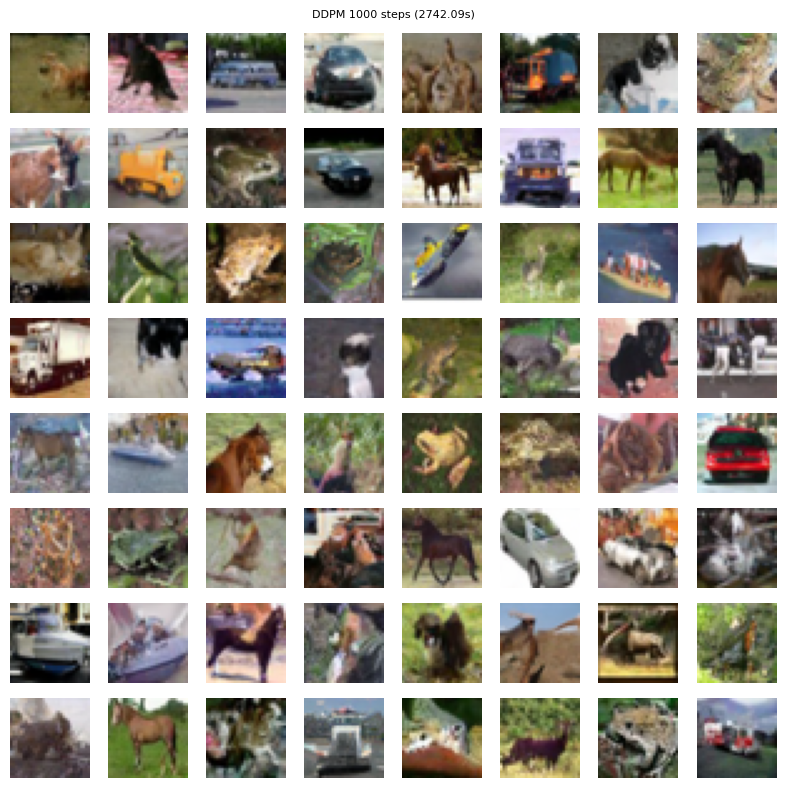

  => saved ddpm_1000_steps.png
DDIM 30 steps:   78.90s


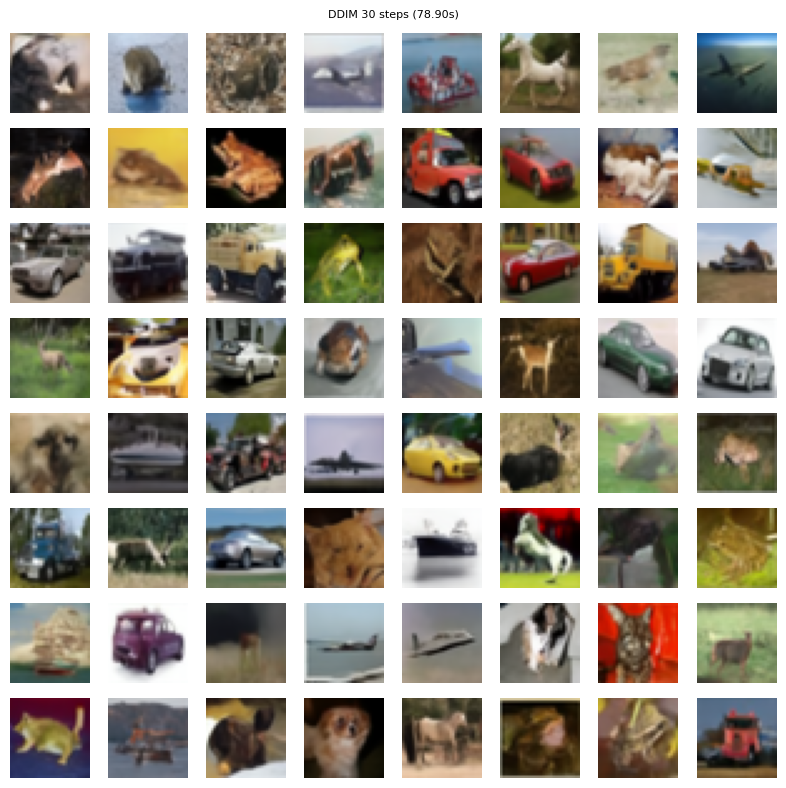

  => saved ddim_30_steps.png
Speedup: 34.8x


In [11]:
# Baseline: original google/ddpm-cifar10-32 — DDPM 1000 steps vs DDIM 30 steps.
model = load_unet()
model.eval()
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M")

imgs_ddpm, t_ddpm = run_sampler(model, DDPMSchedulerFull(), GEN_BATCH, DEVICE)
print(f"DDPM 1000 steps: {t_ddpm:.2f}s")
save_grid(imgs_ddpm, "ddpm_1000_steps.png", f"DDPM 1000 steps ({t_ddpm:.2f}s)")

imgs_ddim, t_ddim = run_sampler(model, DDIMSchedulerFull(30), GEN_BATCH, DEVICE)
print(f"DDIM 30 steps:   {t_ddim:.2f}s")
save_grid(imgs_ddim, "ddim_30_steps.png", f"DDIM 30 steps ({t_ddim:.2f}s)")

print(f"Speedup: {t_ddpm / t_ddim:.1f}x")

#### Distilled student (FID / IS)

Quantitative scores for a distilled checkpoint, using the few-step DDIM sampler.

In [ ]:
# Evaluate a distilled student (FID / IS over 10k samples).
# Point this at whichever checkpoint you want to score.
student = load_unet("checkpoints/fast_professor_8step.pt")
run_eval(student, build_dataset(), DEVICE, num_samples=10000, steps=8)

#### LoRA student (FID / IS)

Rebuilds the frozen base + per-step LoRA heads from the checkpoint and scores it.

In [ ]:
# Evaluate a per-step LoRA student directly from its checkpoint (no training needed).
lora_model, lora_schedule = load_lora_student(CKPT_LORA_8)
run_eval_lora(lora_model, lora_schedule, build_dataset(), DEVICE, num_samples=10000)

#### Post-training quantization (FID / IS / size)

Quantizes the distilled 8-step student to FP16 / BF16 / INT4 and re-scores each.
INT4-NF4 (bitsandbytes) is included only on CUDA; INT4-Emu always runs.

In [ ]:
# Post-training quantization of the distilled 8-step student: FID/IS + size per precision.
quant_base = load_unet(CKPT_DISTILLED_8)             # model to quantize (loaded from checkpoint)
try:
    import bitsandbytes  # noqa: F401
    include_bnb = (DEVICE == "cuda")                 # NF4 needs CUDA + bitsandbytes
except ImportError:
    include_bnb = False

print(f"{'precision':<10}{'size MB':>10}{'FID':>10}{'IS':>10}")
for label, qmodel in make_quant_variants(quant_base, include_bnb=include_bnb):
    size = get_model_size_mb(qmodel)
    fid, isc = run_eval_quant(qmodel.to(DEVICE), build_dataset(), DEVICE, num_samples=10000, steps=8)
    print(f"{label:<10}{size:>10.1f}{fid:>10.3f}{isc:>10.3f}")
    del qmodel
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

#### Lightweight ~3M UNet (FID / IS)

Loads the EMA weights from the checkpoint and scores the few-step DDIM samples.

In [ ]:
# Evaluate the lightweight ~3M UNet directly from its checkpoint at 50 and 20 steps.
small_eval = load_small_unet(CKPT_SMALL_UNET)
small_schedule = SmallDiffusionSchedule()
for steps in (50, 20):
    print(f"\n--- SmallUNet, {steps}-step DDIM ---")
    run_eval_small(small_eval, small_schedule, build_dataset(), DEVICE, num_samples=10000, steps=steps)